# Базовый пайплайн для соревнования по определению контрафакта 

### 1. Загрузка данных

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('ml_ozon_counterfeit_train.csv', index_col=0)

In [3]:
df_test = pd.read_csv('ml_ozon_сounterfeit_test_new_features0.csv', index_col=0)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

df_train = pd.read_csv('ml_ozon_counterfeit_train.csv', index_col=0)
train_ids = df_train["ItemID"]
df_train = df_train.drop("ItemID",axis=1) ## useless feature with unique ids needed only for matching images
df_train = df_train.drop("SellerID",axis=1) ## have only half ids for test ... keep it for later


df_test0 = pd.read_csv('ml_ozon_counterfeit_test.csv', index_col=0)
df_test1 = pd.read_csv('ml_ozon_сounterfeit_test_new_features0.csv', index_col=0)
df_test = pd.concat([df_test0,df_test1],axis=0)

test_ids = df_test["ItemID"]
df_test = df_test.drop("ItemID",axis=1) 
# df_test = df_test.drop("SellerID",axis=1) 

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Target distribution in train:")
print(df_train['resolution'].value_counts())
print()

Train shape: (197198, 42)
Test shape: (31391, 42)
Target distribution in train:
resolution
0    184146
1     13052
Name: count, dtype: int64



### 2. Предобработка данных
Используем 39 числовых признаков

In [2]:
from preprocess_text import clean_text

In [ ]:
numeric_columns = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col != 'resolution']
text_columns =['description','name_rus','CommercialTypeName4','brand_name']


In [4]:
# df_test[text_columns]= df_test[text_columns].fillna('NAN')
df_test[text_columns] = df_test[text_columns].applymap(clean_text)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\3244290848.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_test[text_columns] = df_test[text_columns].applymap(clean_text)
c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py:88: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 88 of the file c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  soup = BeautifulSoup(text)


In [ ]:
# df_train[text_columns]= df_train[text_columns].fillna('NAN')
df_train[text_columns] = df_train[text_columns].applymap(clean_text)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\3902279317.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_train[text_columns] = df_train[text_columns].applymap(clean_text)
c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py:88: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 88 of the file c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  soup = BeautifulSoup(text)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib  # для сохранения
from sklearn.decomposition import TruncatedSVD

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000
)

svd = TruncatedSVD(n_components=32,random_state=42)  # pick embedding size

print("DESC")
# Обучаем на тренировке
X_train_tfidf_desc = vectorizer.fit_transform(df_train['description'].values)
# Применяем к валидации/тесту
X_val_tfidf_desc = vectorizer.transform(df_test['description'].values)


X_emb_desc = svd.fit_transform(X_train_tfidf_desc)
X_val_emb_desc = svd.transform(X_val_tfidf_desc)

svd = TruncatedSVD(n_components=63,random_state=42)  # pick embedding size
print("NAME")
X_train_tfidf_name = vectorizer.fit_transform(df_train['name_rus'].values)
# Применяем к валидации/тесту
X_val_tfidf_name = vectorizer.transform(df_test['name_rus'].values)

X_emb_name = svd.fit_transform(X_train_tfidf_name)
X_val_emb_name = svd.transform(X_val_tfidf_name)

svd = TruncatedSVD(n_components=62,random_state=42)  # pick embedding size
print("TYPE")
X_train_tfidf_type = vectorizer.fit_transform(df_train['CommercialTypeName4'].values)
# Применяем к валидации/тесту
X_val_tfidf_type = vectorizer.transform(df_test['CommercialTypeName4'].values)

X_emb_type = svd.fit_transform(X_train_tfidf_type)
X_val_emb_type = svd.transform(X_val_tfidf_type)


svd = TruncatedSVD(n_components=62,random_state=42)  # pick embedding size
print("BRAND_NAME")
X_train_tfidf_brand = vectorizer.fit_transform(df_train['brand_name'].values)
# Применяем к валидации/тесту
X_val_tfidf_brand = vectorizer.transform(df_test['brand_name'].values)

X_emb_brand = svd.fit_transform(X_train_tfidf_brand)
X_val_emb_brand = svd.transform(X_val_tfidf_brand)




# Сохраняем векторизатор
# joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


DESC
NAME
TYPE
BRAND_NAME


In [7]:
X_emb = np.concat([X_emb_desc,X_emb_name,X_emb_type,X_emb_brand],axis = 1)

In [8]:
X_val_emb = np.concat([X_val_emb_desc,X_val_emb_name,X_val_emb_type,X_val_emb_brand],axis = 1)

In [9]:
X_train = df_train.fillna(0)
X_train = df_train.fillna(0)
y_train = df_train['resolution']
X_test = df_test.fillna(0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print()


X_train shape: (197198, 42)
X_test shape: (31391, 42)



### 3. Обучение модели

In [10]:
X_train[[f'{i}' for i in range(219)]] = X_emb

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\1853346308.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[[f'{i}' for i in range(219)]] = X_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\1853346308.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[[f'{i}' for i in range(219)]] = X_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\1853346308.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

In [11]:
X_test[[f'{i}' for i in range(219)]] = X_val_emb

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\2878387860.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[[f'{i}' for i in range(219)]] = X_val_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\2878387860.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[[f'{i}' for i in range(219)]] = X_val_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\2878387860.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

In [12]:
print(X_test.shape)

(31391, 261)


In [13]:
X_train['image_path'] = train_ids
X_test['image_path'] = test_ids

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\2672442551.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['image_path'] = train_ids
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8472\2672442551.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['image_path'] = test_ids


In [14]:
import pickle
X_train_split = pickle.load(open("X_train_split.pkl","rb"))
X_val_split = pickle.load(open("X_val_split.pkl","rb"))
y_train_split = pickle.load(open("y_train_split.pkl","rb"))
y_val_split = pickle.load(open("y_val_split.pkl","rb"))
# X_test = pickle.load(open("X_test.pkl","rb"))

In [15]:
X_train.loc[X_train_split.index].to_csv("new/X_train_split.csv")
X_train.loc[X_val_split.index].to_csv("new/X_val_split.csv")
X_test.to_csv("new/X_test.csv")

In [45]:
import sys
import math

def main():
    k1,m,k2,p2,n2 = [int(e) for e in input().split()]
    s2 = (p2-1)*m+n2
    ks = math.ceil(k2/s2)
    kp = ks*m
    p1 = k1//kp+1
    n1 = (k1-(p1-1)*m*ks)//ks+1
    print(p1," ",n1)


if __name__ == '__main__':
    main()

2   2


In [32]:
import math
math.ceil(4)

4

In [41]:
aa = pd.DataFrame(y_train_split)

In [42]:
aa['SellerID'] = df['SellerID']

In [46]:
fraud_prop = aa.groupby('SellerID').sum()['resolution']/aa.groupby('SellerID').count()['resolution']

In [89]:
X_train_split['SellerID'] = df["SellerID"]
X_val_split['SellerID'] = df["SellerID"]
X_test['SellerID'] = df_test['SellerID']

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21360\2951020144.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_split['SellerID'] = df["SellerID"]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21360\2951020144.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val_split['SellerID'] = df["SellerID"]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21360\2951020144.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider j

In [90]:
X_train_split = X_train_split.merge(fraud_prop,how = 'left', on = 'SellerID').drop('SellerID',axis=1)

In [91]:
X_val_split = X_val_split.merge(fraud_prop,how = 'left', on = 'SellerID').drop('SellerID',axis=1)

In [92]:
X_test = X_test.merge(fraud_prop,how = 'left', on = 'SellerID').drop('SellerID',axis=1)

In [93]:
X_test = X_test.fillna(-1)

In [94]:
X_val_split = X_val_split.fillna(-1)

In [2]:
import pandas as pd

In [17]:
X_train_split = pd.concat([X_train_split,X_val_split])

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [11]:
X_train_split = X_train_split.loc[df.index]

In [12]:
X_val_split = X_train_split.tail(X_train_split.shape[0]-175000)
X_train_split = X_train_split.head(175000)


In [13]:
y_train_split = df['resolution'].head(X_train_split.shape[0])
y_val_split = df['resolution'].tail(X_val_split.shape[0])

In [24]:
import pandas as pd

In [ ]:
X_train_split = pd.read_csv("counterfeit_multimodal/data/train_ts_s.csv",index_col=0)
y_train_split = X_train_split['label']

In [ ]:
X_val_split = pd.read_csv("counterfeit_multimodal/data/val_ts_s.csv",index_col=0)
y_val_split = X_val_split['label']

In [ ]:
X_test = pd.read_csv("counterfeit_multimodal/data/test_ts_s.csv",index_col=0)

In [30]:
num_col = [col for col in X_train_split.columns if col.startswith("num_")]

In [32]:
X_train_split = X_train_split[num_col]
X_val_split = X_val_split[num_col]
X_test=X_test[num_col]

In [ ]:
# X_train_split = X_train_split.drop(["label",'text','id'],axis = 1)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_split = scaler.fit_transform(X_train_split)
X_val_split = scaler.transform(X_val_split)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs = 16,verbose = 2)
model.fit(X_train_split, y_train_split)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


building tree 1 of 100building tree 2 of 100
building tree 3 of 100

building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100


[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.5s


building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67

[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   22.1s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,f1_score

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print(f1_score(y_val_split,val_pred))
print()

Validation accuracy: 0.9462
Classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     20553
           1       0.63      0.66      0.64      1645

    accuracy                           0.95     22198
   macro avg       0.80      0.81      0.81     22198
weighted avg       0.95      0.95      0.95     22198

0.6435820895522388



[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [28]:
val_pred = (model.predict_proba(X_val_split)[:, 1] > 0.58).astype(int)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))

Validation accuracy: 0.9758
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18415
           1       0.90      0.71      0.80      1305

    accuracy                           0.98     19720
   macro avg       0.94      0.85      0.89     19720
weighted avg       0.97      0.98      0.97     19720



In [14]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 101)
f1_scores = []
probs = model.predict_proba(X_val_split)[:, 1]  # for positive class

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1_scores.append(accuracy_score(y_val_split, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold, "with F1:", max(f1_scores))

Best threshold: 0.47000000000000003 with F1: 0.9773326572008113


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(np.arange(256),model.feature_importances_)

NameError: name 'np' is not defined

In [2]:
from sklearn.metrics import f1_score

In [3]:
import numpy as np

In [16]:
labels = np.array([1 for i in range(1000)] + [0 for i in range(10000)])

In [17]:
preds = np.zeros(11000)

In [19]:
f1_score(labels,preds,average='binary')

0.0

In [22]:
from sklearn.metrics import accuracy_score,classification_report
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9773
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18415
           1       0.87      0.77      0.82      1305

    accuracy                           0.98     19720
   macro avg       0.93      0.88      0.90     19720
weighted avg       0.98      0.98      0.98     19720




In [50]:
a = dict()
print(a.setdefault("1","YES"))

YES


In [ ]:
import sys
from functools import reduce
from itertools import accumulate


def main():
    watafa = input()
    aaa = [int(i) for i in input().split()]
    aaa = accumulate(aaa)
    print(reduce(lambda x,y: str(x)+" "+str(y),aaa))


if __name__ == '__main__':
    main()


10 6 11 11 13


In [54]:
import sys
from functools import reduce

def main():
    aaa = set(input().split())
    bbb = input().split()
    ccc = sorted(list(aaa.intersection(bbb)),key = lambda x: int(x))
    print(reduce(lambda x,y:x+" "+y,ccc))


if __name__ == '__main__':
    main()


2 4


In [49]:
a.get('1','NO')

'YES'

In [14]:

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9768
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     36830
           1       0.87      0.76      0.81      2610

    accuracy                           0.98     39440
   macro avg       0.93      0.88      0.90     39440
weighted avg       0.98      0.98      0.98     39440




In [119]:

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9767
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     36830
           1       0.88      0.75      0.81      2610

    accuracy                           0.98     39440
   macro avg       0.93      0.87      0.90     39440
weighted avg       0.98      0.98      0.98     39440




,rating_1_count,rating_2_count,rating_3_count,rating_4_count,rating_5_count,comments_published_count,photos_published_count,videos_published_count,PriceDiscounted,item_time_alive,...,118,119,120,121,122,123,124,125,126,127
id,,,,,,,,,,,,,,,,,,,,,
159385,6.0,4.0,4.0,3.0,32.0,3.0,6.0,0.0,688.436773,195,...,0.011582,-0.000179,-0.002998,0.004652,5.438303e-03,-3.246763e-04,0.006833,5.690639e-03,3.408409e-03,-8.871105e-03
288616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,663.157297,972,...,0.393118,-0.033866,-0.108054,0.123997,6.568067e-02,1.107214e-01,-0.089651,-1.402209e-02,-1.557652e-02,-4.410085e-02
108090,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,606.573197,1596,...,-0.001420,0.000943,0.001423,0.001505,8.550990e-04,-1.195339e-03,-0.000204,1.570271e-03,-2.000337e-04,5.840972e-04
415607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,856.755162,386,...,-0.000002,-0.000002,-0.000004,-0.000003,-6.799090e-07,3.044780e-06,0.000001,6.921797e-07,2.184893e-07,-4.531972e-07
332391,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,822.274833,428,...,-0.000002,-0.000002,-0.000004,-0.000003,-6.799090e-07,3.044780e-06,0.000001,6.921797e-07,2.184893e-07,-4.531972e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159865,4.0,1.0,0.0,6.0,60.0,76.0,29.0,9.0,1013.750244,605,...,0.000296,0.000961,0.000207,0.001815,1.096450e-04,-4.966793e-05,-0.001024,4.119633e-05,-2.724669e-03,-1.189154e-03
299636,0.0,0.0,0.0,1.0,31.0,33.0,26.0,12.0,1177.025024,45,...,0.014032,0.017750,0.031045,0.030611,-1.501144e-02,-4.680527e-02,-0.014623,-1.989679e-03,-6.366643e-03,1.499460e-02
24145,1.0,1.0,1.0,0.0,27.0,10.0,15.0,0.0,1004.280743,477,...,0.003202,-0.000253,-0.002478,-0.000273,-5.958416e-04,3.504893e-03,-0.028063,2.171606e-02,8.780544e-03,-5.264542e-03


<BarContainer object of 32 artists>

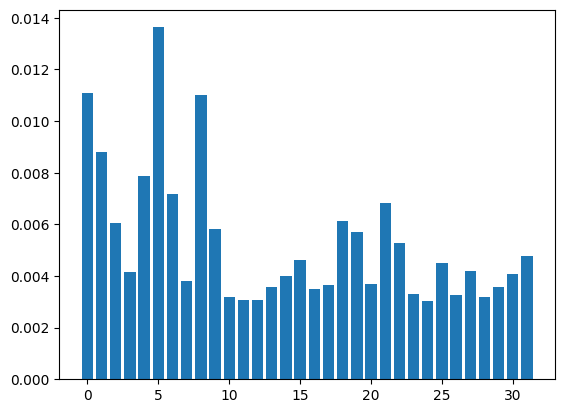

In [142]:
import matplotlib.pyplot as plt
plt.bar(np.arange(32),model.feature_importances_[-32:])

In [ ]:
model.feature_importances_.argsort()
[print(i,c) for i,c in enumerate(X_train.columns[model.feature_importances_.argsort()])];

In [15]:

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9717
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     36830
           1       0.88      0.66      0.76      2610

    accuracy                           0.97     39440
   macro avg       0.93      0.83      0.87     39440
weighted avg       0.97      0.97      0.97     39440




In [ ]:
from transformers

In [ ]:
from transformers import CLIPModel, BlipModel

In [23]:

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9718
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     36830
           1       0.88      0.67      0.76      2610

    accuracy                           0.97     39440
   macro avg       0.93      0.83      0.87     39440
weighted avg       0.97      0.97      0.97     39440




In [1]:
import pickle
import torch

In [2]:
X_test = pickle.load(open("X_test.pkl","rb"))

In [4]:
torch.tensor(X_test.iloc[0]).shape

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24124\1888239112.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  torch.tensor(X_test.iloc[0]).shape


torch.Size([256])

In [8]:
X_test.iloc[0]

rating_1_count    0.000000e+00
rating_2_count    0.000000e+00
rating_3_count    0.000000e+00
rating_4_count    0.000000e+00
rating_5_count    0.000000e+00
                      ...     
214              -7.171034e-18
215              -5.229504e-18
216               1.229914e-16
217               5.656791e-17
218              -1.392761e-16
Name: 17384, Length: 256, dtype: float64

In [27]:
import matplotlib.pyplot as plt

In [39]:
X_train

,rating_1_count,rating_2_count,rating_3_count,rating_4_count,rating_5_count,comments_published_count,photos_published_count,videos_published_count,PriceDiscounted,item_time_alive,...,86,87,88,89,90,91,92,93,94,95
id,,,,,,,,,,,,,,,,,,,,,
159385,6.0,4.0,4.0,3.0,32.0,3.0,6.0,0.0,688.436773,195,...,-0.000261,0.031583,-0.019785,0.034022,0.078870,0.005816,0.013921,-0.032301,0.008647,0.004539
288616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,663.157297,972,...,0.000061,-0.004682,0.002239,-0.000718,0.013932,-0.000187,-0.005424,0.008201,-0.003607,0.000003
108090,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,606.573197,1596,...,0.000581,-0.071483,0.065970,-0.178806,0.193355,-0.093769,0.010779,-0.150785,-0.007471,0.033517
415607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,856.755162,386,...,-0.000043,-0.000158,-0.001793,-0.000997,0.000163,-0.001999,0.000425,0.000783,0.000104,0.004164
332391,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,822.274833,428,...,-0.000043,-0.000158,-0.001793,-0.000997,0.000163,-0.001999,0.000425,0.000783,0.000104,0.004164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159865,4.0,1.0,0.0,6.0,60.0,76.0,29.0,9.0,1013.750244,605,...,0.000065,-0.012574,-0.014451,-0.024877,0.006179,0.003255,-0.015807,-0.007028,-0.007217,-0.006211
299636,0.0,0.0,0.0,1.0,31.0,33.0,26.0,12.0,1177.025024,45,...,-0.000205,-0.011066,-0.006823,0.003816,0.007509,0.016664,0.005226,0.002240,-0.000236,0.002899
24145,1.0,1.0,1.0,0.0,27.0,10.0,15.0,0.0,1004.280743,477,...,-0.000221,0.002330,0.003816,0.008877,0.040205,0.010764,-0.062060,0.045403,0.029585,-0.008221


<BarContainer object of 96 artists>

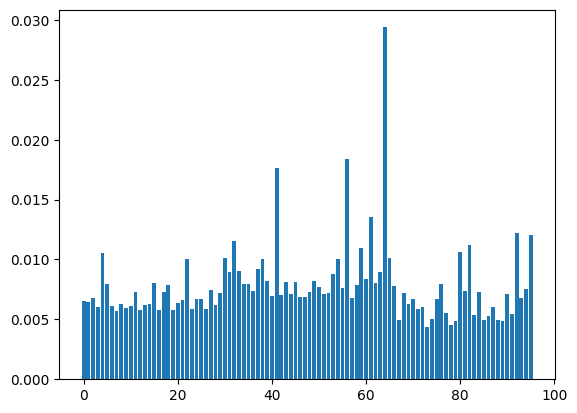

In [52]:
plt.bar(np.arange(96),model.feature_importances_[-96:])

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier


model = GradientBoostingClassifier(n_estimators=1000,random_state=42,verbose=1,warm_start=True,n_iter_no_change=10)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()


      Iter       Train Loss   Remaining Time 
         1           0.4475           54.31m
         2           0.4192           53.77m
         3           0.4004           53.78m
         4           0.3866           53.61m
         5           0.3754           53.44m
         6           0.3671           53.63m
         7           0.3572           53.63m
         8           0.3494           53.47m
         9           0.3441           53.53m
        10           0.3375           53.45m
        20           0.3010           52.76m
        30           0.2834           52.28m
        40           0.2724           51.76m
        50           0.2628           51.41m
        60           0.2571           50.78m
        70           0.2514           50.20m
        80           0.2478           49.73m
        90           0.2443           49.15m
       100           0.2410           48.61m
       200           0.2178           43.44m
       300           0.2010           38.14m
       40

### 4. Формирование submission.csv

In [ ]:

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

val_pred = model.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_val_split, val_pred))
print()

Validation accuracy: 0.9659
Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     36830
           1       0.90      0.55      0.68      2610

    accuracy                           0.97     39440
   macro avg       0.93      0.77      0.83     39440
weighted avg       0.96      0.97      0.96     39440




In [39]:
import pandas as pd
test_predictions = (model.predict_proba(X_test)[:, 1] > 0.70).astype(int)

submission = pd.DataFrame({
    'id': df_test.index,
    'prediction': test_predictions
})

submission.to_csv('submission.csv', index=False)


print(f"Создан файл submission.csv с {len(submission)} предсказаниями")
print(f"Распределение предсказаний:")
print(submission['prediction'].value_counts())
print()

Создан файл submission.csv с 22760 предсказаниями
Распределение предсказаний:
prediction
0    22041
1      719
Name: count, dtype: int64



[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
